In [2]:
# Import pandas for loading the engineered datasets
import pandas as pd

# Load the engineered training data and target
X_train = pd.read_csv("/app/data/X_train_engineered.csv")
y_train = pd.read_csv("/app/data/y_train.csv")

# Load the engineered validation data and target
X_val = pd.read_csv("/app/data/X_val_engineered.csv")
y_val = pd.read_csv("/app/data/y_val.csv")

# Load the engineered test data and target
X_test = pd.read_csv("/app/data/X_test_engineered.csv")
y_test = pd.read_csv("/app/data/y_test.csv")

# Check the dimensions to confirm that the engineered datasets were loaded correctly
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (67532, 58)
X_val: (14472, 58)
X_test: (14472, 58)


In [3]:
# Import Logistic Regression as our baseline classification model
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics for measuring classification performance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [4]:
# Create a Logistic Regression baseline model
# class_weight="balanced" gives more importance to the minority class (late orders)
baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train the baseline model using only the training data
baseline_model.fit(X_train, y_train["is_late"])

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [5]:
# Import StandardScaler to put numerical features on comparable scales
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Learn scaling parameters from the training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling parameters to validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Create the Logistic Regression baseline model with balanced class weights
baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train the baseline model using the scaled training data
baseline_model.fit(
    X_train_scaled,
    y_train["is_late"]
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [7]:
# Generate predictions for the validation set
y_val_pred = baseline_model.predict(X_val_scaled)

# Generate probability predictions for the late class
y_val_proba = baseline_model.predict_proba(X_val_scaled)[:, 1]

In [8]:
# Calculate classification metrics on the validation set
accuracy = accuracy_score(y_val["is_late"], y_val_pred)
precision = precision_score(y_val["is_late"], y_val_pred)
recall = recall_score(y_val["is_late"], y_val_pred)
f1 = f1_score(y_val["is_late"], y_val_pred)
roc_auc = roc_auc_score(y_val["is_late"], y_val_proba)

# Display the baseline validation performance
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.6607
Precision: 0.1246
Recall:    0.5281
F1 Score:  0.2016
ROC-AUC:   0.6402


In [9]:
# Store the baseline model performance for comparison with future models
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "ROC-AUC": [roc_auc]
})

# Display the baseline results
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.660655,0.124573,0.528109,0.201593,0.640221


In [10]:
# Import Random Forest for a nonlinear tree-based classification model
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
# class_weight="balanced" gives more importance to the minority class
random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest using the original engineered features
random_forest.fit(
    X_train,
    y_train["is_late"]
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [11]:
# Generate predictions for the validation set
y_val_pred_rf = random_forest.predict(X_val)

# Generate probability predictions for the late class
y_val_proba_rf = random_forest.predict_proba(X_val)[:, 1]

# Calculate validation metrics for Random Forest
rf_accuracy = accuracy_score(y_val["is_late"], y_val_pred_rf)
rf_precision = precision_score(y_val["is_late"], y_val_pred_rf)
rf_recall = recall_score(y_val["is_late"], y_val_pred_rf)
rf_f1 = f1_score(y_val["is_late"], y_val_pred_rf)
rf_roc_auc = roc_auc_score(y_val["is_late"], y_val_proba_rf)

# Display Random Forest validation performance
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Accuracy:  0.9101
Precision: 0.3839
Recall:    0.1789
F1 Score:  0.2440
ROC-AUC:   0.7697


In [12]:
# Evaluate different probability thresholds to find a better balance
# between precision and recall for the late-order class
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:
    # Convert predicted probabilities into class predictions using the threshold
    y_threshold_pred = (y_val_proba_rf >= threshold).astype(int)

    # Calculate precision, recall, and F1 for the current threshold
    threshold_precision = precision_score(
        y_val["is_late"],
        y_threshold_pred,
        zero_division=0
    )

    threshold_recall = recall_score(
        y_val["is_late"],
        y_threshold_pred,
        zero_division=0
    )

    threshold_f1 = f1_score(
        y_val["is_late"],
        y_threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {threshold_precision:.4f} | "
        f"Recall: {threshold_recall:.4f} | "
        f"F1: {threshold_f1:.4f}"
    )

Threshold: 0.20 | Precision: 0.1969 | Recall: 0.6380 | F1: 0.3009
Threshold: 0.25 | Precision: 0.2303 | Recall: 0.5358 | F1: 0.3222
Threshold: 0.30 | Precision: 0.2635 | Recall: 0.4489 | F1: 0.3321
Threshold: 0.35 | Precision: 0.2980 | Recall: 0.3620 | F1: 0.3269
Threshold: 0.40 | Precision: 0.3279 | Recall: 0.2930 | F1: 0.3095
Threshold: 0.45 | Precision: 0.3514 | Recall: 0.2325 | F1: 0.2799
Threshold: 0.50 | Precision: 0.3820 | Recall: 0.1848 | F1: 0.2491


In [13]:
# Select the probability threshold that achieved the highest validation F1 score
best_threshold = 0.30

# Generate final validation predictions using the selected threshold
y_val_pred_rf_tuned = (
    y_val_proba_rf >= best_threshold
).astype(int)

# Calculate the final validation metrics using the selected threshold
tuned_precision = precision_score(
    y_val["is_late"],
    y_val_pred_rf_tuned
)

tuned_recall = recall_score(
    y_val["is_late"],
    y_val_pred_rf_tuned
)

tuned_f1 = f1_score(
    y_val["is_late"],
    y_val_pred_rf_tuned
)

# Display the selected threshold and its validation performance
print(f"Selected threshold: {best_threshold:.2f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1 Score:  {tuned_f1:.4f}")

Selected threshold: 0.30
Precision: 0.2635
Recall:    0.4489
F1 Score:  0.3321


In [14]:
# Import HistGradientBoostingClassifier as a stronger nonlinear model
from sklearn.ensemble import HistGradientBoostingClassifier

# Create the Gradient Boosting model
# The model can capture nonlinear relationships between the engineered features
gradient_boosting = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.08,
    max_leaf_nodes=31,
    random_state=42
)

# Train the model using only the training data
gradient_boosting.fit(
    X_train,
    y_train["is_late"]
)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.08
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [15]:
# Generate probability predictions for the validation set
y_val_proba_gb = gradient_boosting.predict_proba(X_val)[:, 1]

# Generate predictions using the default 0.50 probability threshold
y_val_pred_gb = (y_val_proba_gb >= 0.50).astype(int)

# Calculate validation metrics for Gradient Boosting
gb_accuracy = accuracy_score(y_val["is_late"], y_val_pred_gb)
gb_precision = precision_score(y_val["is_late"], y_val_pred_gb)
gb_recall = recall_score(y_val["is_late"], y_val_pred_gb)
gb_f1 = f1_score(y_val["is_late"], y_val_pred_gb)
gb_roc_auc = roc_auc_score(y_val["is_late"], y_val_proba_gb)

# Display Gradient Boosting validation performance
print(f"Accuracy:  {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall:    {gb_recall:.4f}")
print(f"F1 Score:  {gb_f1:.4f}")
print(f"ROC-AUC:   {gb_roc_auc:.4f}")

Accuracy:  0.9183
Precision: 0.4167
Recall:    0.0170
F1 Score:  0.0327
ROC-AUC:   0.7809


In [16]:
# Evaluate different probability thresholds for Gradient Boosting
# to find a better balance between precision and recall
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:
    # Convert predicted probabilities into class predictions
    y_threshold_pred = (y_val_proba_gb >= threshold).astype(int)

    # Calculate precision, recall, and F1 for the current threshold
    threshold_precision = precision_score(
        y_val["is_late"],
        y_threshold_pred,
        zero_division=0
    )

    threshold_recall = recall_score(
        y_val["is_late"],
        y_threshold_pred,
        zero_division=0
    )

    threshold_f1 = f1_score(
        y_val["is_late"],
        y_threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {threshold_precision:.4f} | "
        f"Recall: {threshold_recall:.4f} | "
        f"F1: {threshold_f1:.4f}"
    )

Threshold: 0.10 | Precision: 0.2092 | Recall: 0.6022 | F1: 0.3105
Threshold: 0.15 | Precision: 0.2770 | Recall: 0.4506 | F1: 0.3431
Threshold: 0.20 | Precision: 0.3251 | Recall: 0.3237 | F1: 0.3244
Threshold: 0.25 | Precision: 0.3549 | Recall: 0.2385 | F1: 0.2853
Threshold: 0.30 | Precision: 0.3898 | Recall: 0.1763 | F1: 0.2428
Threshold: 0.35 | Precision: 0.4131 | Recall: 0.1235 | F1: 0.1902
Threshold: 0.40 | Precision: 0.4681 | Recall: 0.0750 | F1: 0.1292
Threshold: 0.45 | Precision: 0.5368 | Recall: 0.0434 | F1: 0.0804
Threshold: 0.50 | Precision: 0.4167 | Recall: 0.0170 | F1: 0.0327


In [17]:
# Select the probability threshold that achieved the highest validation F1 score
best_gb_threshold = 0.15

# Generate final validation predictions using the selected threshold
y_val_pred_gb_tuned = (
    y_val_proba_gb >= best_gb_threshold
).astype(int)

# Calculate the final validation metrics using the selected threshold
gb_tuned_precision = precision_score(
    y_val["is_late"],
    y_val_pred_gb_tuned
)

gb_tuned_recall = recall_score(
    y_val["is_late"],
    y_val_pred_gb_tuned
)

gb_tuned_f1 = f1_score(
    y_val["is_late"],
    y_val_pred_gb_tuned
)

# Display the selected threshold and validation performance
print(f"Selected threshold: {best_gb_threshold:.2f}")
print(f"Precision: {gb_tuned_precision:.4f}")
print(f"Recall:    {gb_tuned_recall:.4f}")
print(f"F1 Score:  {gb_tuned_f1:.4f}")

Selected threshold: 0.15
Precision: 0.2770
Recall:    0.4506
F1 Score:  0.3431


In [18]:
# Compare the validation performance of the trained models
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        gb_roc_auc
    ],
    "Precision": [
        precision,
        tuned_precision,
        gb_tuned_precision
    ],
    "Recall": [
        recall,
        tuned_recall,
        gb_tuned_recall
    ],
    "F1": [
        f1,
        tuned_f1,
        gb_tuned_f1
    ]
})

# Display the validation model comparison
model_comparison.sort_values(
    by="F1",
    ascending=False
)

,Model,ROC-AUC,Precision,Recall,F1
2,Gradient Boosting,0.780890,0.276963,0.450596,0.343061
1,Random Forest,0.769708,0.263500,0.448893,0.332073
0,Logistic Regression,0.640221,0.124573,0.528109,0.201593


In [19]:
# Generate probability predictions for the unseen test set
y_test_proba = gradient_boosting.predict_proba(X_test)[:, 1]

# Apply the threshold selected using the validation set
y_test_pred = (
    y_test_proba >= best_gb_threshold
).astype(int)

# Calculate final test performance
test_accuracy = accuracy_score(
    y_test["is_late"],
    y_test_pred
)

test_precision = precision_score(
    y_test["is_late"],
    y_test_pred
)

test_recall = recall_score(
    y_test["is_late"],
    y_test_pred
)

test_f1 = f1_score(
    y_test["is_late"],
    y_test_pred
)

test_roc_auc = roc_auc_score(
    y_test["is_late"],
    y_test_proba
)

# Display the final test performance
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")

Accuracy:  0.8579
Precision: 0.2776
Recall:    0.4693
F1 Score:  0.3488
ROC-AUC:   0.7829


In [20]:
# Store the final test-set performance of the selected Gradient Boosting model
final_results = pd.DataFrame({
    "Model": ["Gradient Boosting"],
    "Threshold": [best_gb_threshold],
    "Accuracy": [test_accuracy],
    "Precision": [test_precision],
    "Recall": [test_recall],
    "F1": [test_f1],
    "ROC-AUC": [test_roc_auc]
})

# Display the final model performance
final_results

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.15,0.857863,0.277582,0.469336,0.348845,0.782852


In [22]:
# Import permutation importance to measure how much each feature affects model performance
from sklearn.inspection import permutation_importance

# Calculate feature importance using the validation data
# The validation set is used here because the test set must remain untouched after final evaluation
perm_importance = permutation_importance(
    gradient_boosting,
    X_val,
    y_val["is_late"],
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Create a table containing each feature and its average importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": perm_importance.importances_mean
})

# Sort features from the most important to the least important
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

# Display the 15 most important features
feature_importance.head(15)

,feature,importance
18,purchase_month,0.013428
17,purchase_year,0.011302
49,customer_state_SP,0.010572
5,total_freight,0.008945
14,geo_lng,0.007586
0,customer_zip_code_prefix,0.006853
42,customer_state_RJ,0.005803
1,item_count,0.002236
35,customer_state_MS,0.001294
33,customer_state_MA,0.001243


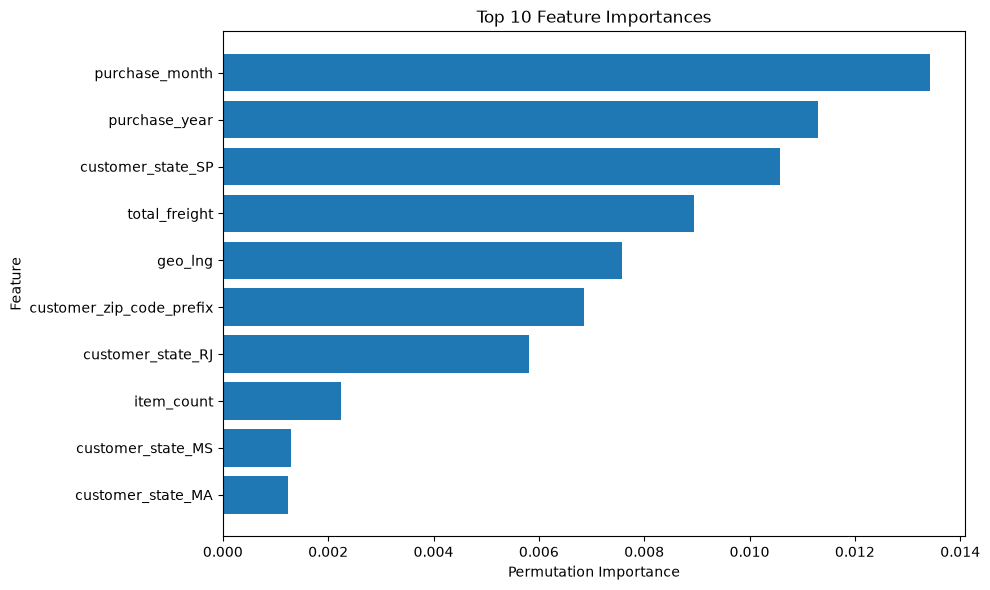

In [23]:
# Select the 10 most important features for visualization
top_features = feature_importance.head(10).sort_values(
    by="importance",
    ascending=True
)

# Plot the permutation importance of the top features
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.tight_layout()
plt.show()

In [25]:
# Save the permutation feature importance results for use in Notebook 7
feature_importance.to_csv(
    "/app/data/feature_importance.csv",
    index=False
)

# Confirm that the feature importance results were saved successfully
print("Feature importance saved successfully.")

Feature importance saved successfully.


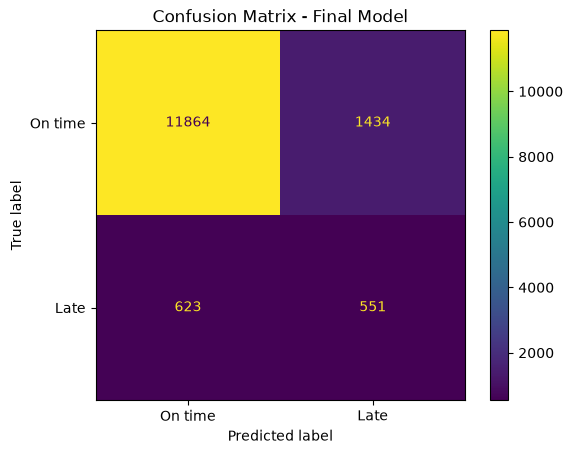

In [24]:
# Import the confusion matrix function for final model evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix using the final test predictions
cm = confusion_matrix(
    y_test["is_late"],
    y_test_pred
)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On time", "Late"]
)

disp.plot()

plt.title("Confusion Matrix - Final Model")
plt.show()